# Section 2: Sampling, LLN, CLT

# 1. The Law of Large Numbers

We first show the law of large numbers. Suppose that in the overall population, annual wages are normally distributed with mean = 55 (USD 55k) and standard deviation = 15 (USD 15k). We can draw random samples of a certain number of individuals to estimate what the overall average wage is (for example, we could do this every year to estimate whether economic well-being in the US improves over time).

We learn some more syntax in R:
* `getwd` to set the working directory
* `set.seed(number)` to set a random seed and 'fix' the random number generator, to ensure replicability of random draws
* `rnorm(N, mean, sd)` for random draws from a normal distribution
* `cumsum`, the cumulative summation of a vector

First, we set up our environment and generate the data.

In [1]:
# ===== 0. Set environment and directory =====
getwd()
library(ggplot2)
options(warn = -1)
# ===== 1. Law of Large Numbers (LLN) =====
set.seed(123) # set.seed() fixes the random number generator so that

# 1.1.1 Definition of parameters
mu <- 55    # in thousands of dollars
sigma <- 15 # in thousands of dollars
N <- 5000
wage <- rnorm(N, mean=mu, sd=sigma) # simulate wages (in $000s)
true_mean <- mu # population mean
running_mean <- cumsum(wage) / (1:N) # running sample mean as n increases



[1] "/home/jovyan/econ140_fall2025/Datahub"

Next, let us plot the data. What happens to the sample mean as the sample size becomes larger and larger?

[1] "Drawing 5 wages from distribution"


[1] 60.65104

[1] 55.96858

[1] 54.96021

[1] 52.3135

...

[1] 55.54435

[1] 56.49618

[1] 55.47837

[1] 54.06919

[1] 55.04415

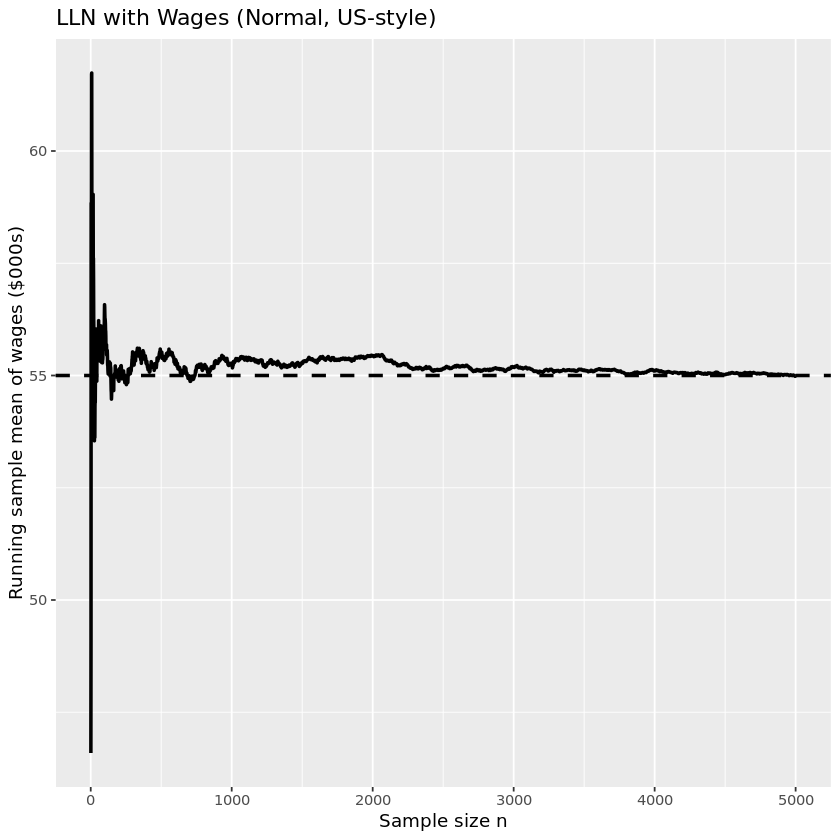

In [2]:


# 1.1.2 Plot: running mean vs. sample size 
lln_data <- data.frame(sample_size = 1:N, running_mean = running_mean)
plot_mean = ggplot(lln_data, aes(x = sample_size, y = running_mean)) +
  geom_line(linewidth = 1) +
  geom_hline(yintercept = true_mean, linetype = "dashed", size = 1) +
  labs(x = "Sample size n", 
       y = "Running sample mean of wages ($000s)",
       title = "LLN with Wages (Normal, US-style)")
print(plot_mean)


##### 1.2 More intuition for this exercise
# 1.2.1 Check a couple of examples
# Draw, say, 5 wages and compute their average:
print("Drawing 5 wages from distribution")
mean(rnorm(5, mean=55, sd=15))
# Do it again:
mean(rnorm(5, mean=55, sd=15))
mean(rnorm(5, mean=55, sd=15))
mean(rnorm(5, mean=55, sd=15))
mean(rnorm(5, mean=55, sd=15))

#→Another average, different but still noisy!
print("Drawing 50 wages from distribution")

# Draw, say, 50 wages and compute their average:
mean(rnorm(50, mean=55, sd=15))
# Do it again:
mean(rnorm(50, mean=55, sd=15))
mean(rnorm(50, mean=55, sd=15))
mean(rnorm(50, mean=55, sd=15))
mean(rnorm(50, mean=55, sd=15))



We ran this experiment only once, letting the sample size become "big". Next, we run a Monte Carlo Simulation. 
A Monte Carlo Simulation is very useful in statistics and econometrics to study the properties of estimators
(such as sample means). It simply means that we run a random experiment many times and study what happens 
as we repeat it.

In our case, we take our initial sample sizes (5 and 50), and repeat the experiment 10,000 times. As we increase the sample size (from 5 to 50 to 500), we "converge" to the true population mean.

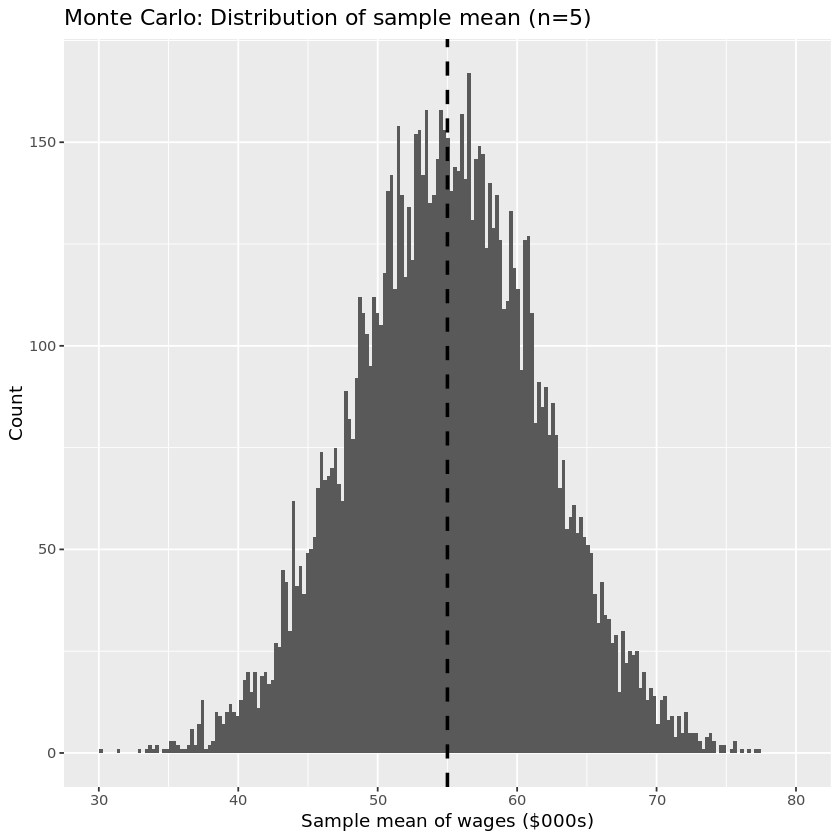

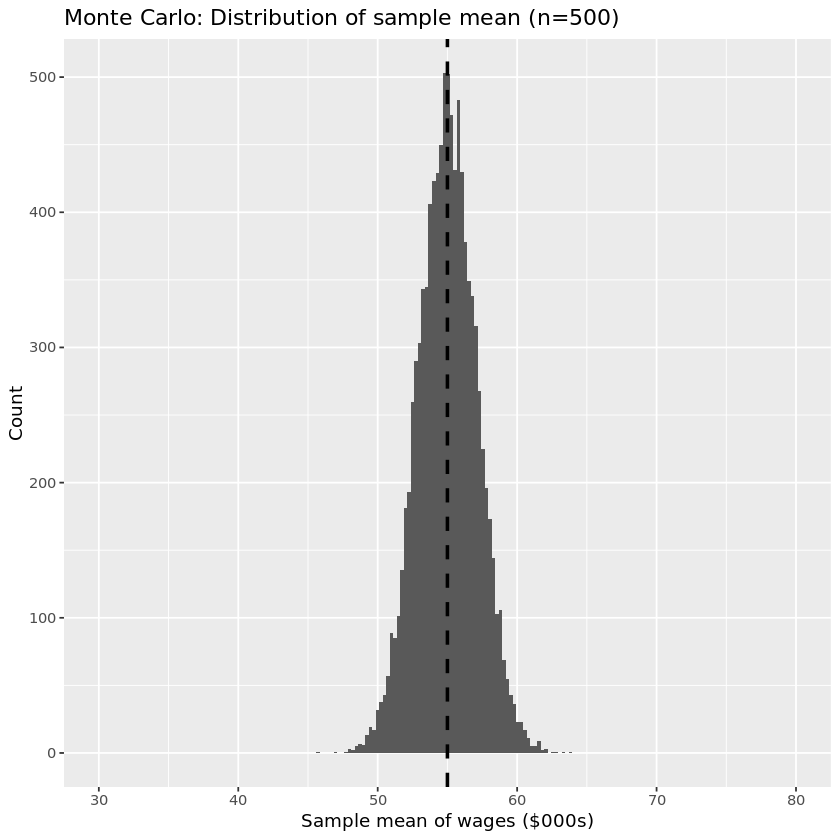

In [3]:

# 1.2.2 Many replications = Monte Carlo
#Now repeat that little experiment thousands of times and look at the 
# distribution of the sample mean:

B <- 10000   # number of Monte Carlo replications
n <- 5      # sample size
mc_means_small <- replicate(B, mean(rnorm(n, mean=55, sd=15)))
small_sample_data <- data.frame(means = mc_means_small)
ggplot(small_sample_data, aes(x = means)) +
  geom_histogram(bins = 200) +
  geom_vline(xintercept = 55, linetype = "dashed", size = 1) +
  xlim(30, 80) +
  labs(x = "Sample mean of wages ($000s)",
       y = "Count",
       title = "Monte Carlo: Distribution of sample mean (n=5)") 

#→This shows that when n=5, the averages bounce around a lot.

# 1.2.3 Show the LLN "kicking in"
# Change n to 50 or 500
n <- 50
mc_means_large <- replicate(B, mean(rnorm(n, mean=55, sd=15)))
large_sample_data <- data.frame(means = mc_means_large)
ggplot(large_sample_data, aes(x = means)) +
  geom_histogram(bins = 200) +
  geom_vline(xintercept = 55, linetype = "dashed", size = 1) +
  xlim(30, 80) +
  labs(x = "Sample mean of wages ($000s)",
       y = "Count", 
       title = "Monte Carlo: Distribution of sample mean (n=500)") 
#→Now the histogram is sharply centered near 55.
#→That contrast (wide vs. narrow) is the Monte Carlo evidence of LLN.


## 2. The Central Limit Theorem

The Central Limit Theorem states that, across experiments, the distribution of sample means (of i.i.d. random variables) we get converges in distribution to a normal distribution, no matter how the initial random variable is distributed. 

In our example, we can show this by increasing the number of Monte Carlo Experiments.

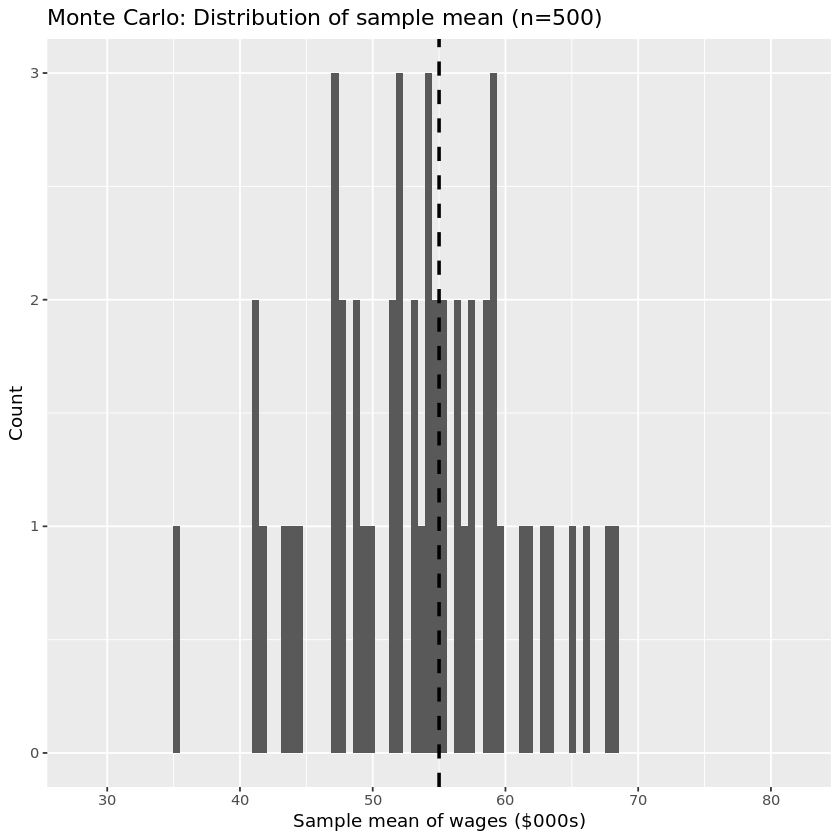

In [4]:
# Increase B and see how the distribution becomes increasingly normal
B = 50
n <- 5
mc_means_large <- replicate(B, mean(rnorm(n, mean=55, sd=15)))
large_sample_data <- data.frame(means = mc_means_large)
ggplot(large_sample_data, aes(x = means)) +
  geom_histogram(bins = 100) +
  geom_vline(xintercept = 55, linetype = "dashed", size = 1) +
  xlim(55-15*4/sqrt(n), 55+15*4/sqrt(n)) +
  labs(x = "Sample mean of wages ($000s)",
       y = "Count", 
       title = "Monte Carlo: Distribution of sample mean (n=500)") 

In this case, income was already distributed normally - so this may not be very surprising (what is the distribution of the sum of independent normal random variables)? 

Let us go over the Settlers of Catan experiment.

As a note: I use the sum across dice in this example, but the average across dice works equally well - it would just be dividing things by N. There is also some code that we do not have to understand to calculate the limits of the graph.

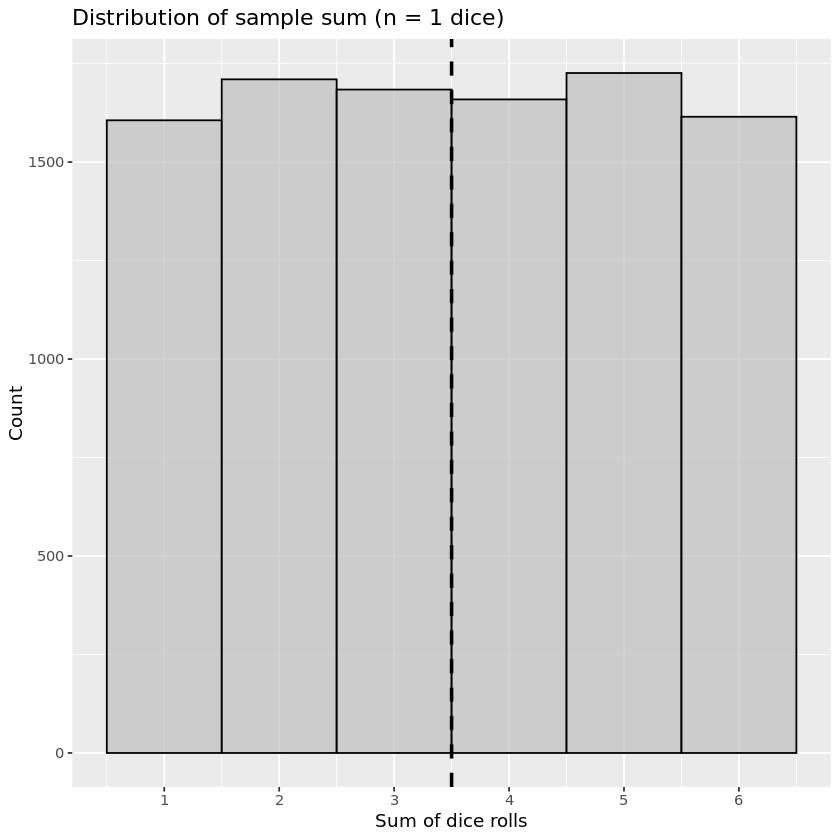

In [5]:
##### 2.1 CLT with a Fair Die (include n=1 baseline) 
# Goal: Show sample sums of die rolls become bell-shaped as n grows.
set.seed(789)
# 2.1.1 Definition of parameters
mu_die <- 3.5 # true mean of single die
K <- 10000 # Monte Carlo repetitions
number_of_dice <- 1

# Let us roll "number_of_dice" dice and record the sum of the values - and repeat that K times to see the distribution.
sums_dice <- replicate(K, sum(sample(1:6, size=number_of_dice, replace=TRUE))) 
sums_dice <- data.frame(sums_dice)
# Note: We could just as well divide by the number of dice and get the average.


## Some auxiliary calculations for the graph - can fully ignore these!
# Calculate limits: use full range for small n, reasonable range for large n
min_sum <- number_of_dice
max_sum <- 6 * number_of_dice
expected_sum <- mu_die * number_of_dice
std_sum <- sqrt(number_of_dice * (35/12)) # variance of single die = 35/12

if (number_of_dice <= 10) {
  # For small n, show full range
  xlim_min <- min_sum - 0.5
  xlim_max <- max_sum + 0.5
    bin_width = 1
} else {
  # For large n, show mean +/- 3 standard deviations
  xlim_min <- expected_sum - 3 * std_sum
  xlim_max <- expected_sum + 3 * std_sum
    bin_width = sqrt(number_of_dice)/10
}

# Plot
ggplot(sums_dice, aes(x = sums_dice)) +
  geom_histogram(binwidth = bin_width, 
                 fill = "grey", 
                 color = "black", 
                 alpha = 0.7) +
  geom_vline(xintercept = expected_sum, linetype = "dashed", size = 1) +
  scale_x_continuous(n.breaks = 10) +
  coord_cartesian(xlim = c(xlim_min, xlim_max)) +
  labs(x = "Sum of dice rolls",
       y = "Count", 
       title = paste("Distribution of sample sum (n =", number_of_dice, "dice)"))



In [6]:
print("Thank you!")

[1] "Thank you!"
